# HW01


In [1]:
# Configure Plotly to render static PNGs in this notebook
import plotly.io as pio

# Produce PNG outputs instead of interactive HTML
pio.renderers.default = "png"

# If you want interactive HTML instead, comment the line above and uncomment below:
# pio.renderers.default = "notebook_connected"

# Optional: improve PNG resolution when Kaleido is available
pio.defaults.default_scale = 2
pio.defaults.default_width = 900
pio.defaults.default_height = 600

In [28]:
# imports
import numpy as np
import plotly.graph_objects as go

In [17]:
# Settings for the LQR
T = 20
A = np.array([[1, 1], [0, 1]])
B = np.array([[0], [1]])
x_0 = np.array([[5], [0]])

position_penalty = [(np.array([[q, 0], [0, 1]]), 1, np.identity(2)) for q in (0.1, 10)]
control_penalty = [(np.identity(2), r, np.identity(2)) for r in (0.1, 10)]
terminal_penalty = [(np.identity(2), 1, np.identity(2) * q_f) for q_f in (3, 10)]
benchmark_penalty = [(np.identity(2), 1, np.identity(2) * 1)]

penalty = {
    "position": position_penalty,
    "control": control_penalty,
    "terminal": terminal_penalty,
    "benchmark": benchmark_penalty,
}


def dynamics(x_prev: np.ndarray, u: np.ndarray) -> np.ndarray:
    return A @ x_prev + B @ u

In [14]:
def P(
    T: int,
    A: np.ndarray,
    B: np.ndarray,
    Q: np.ndarray,
    Q_f: np.ndarray,
    r: float,
    t: int = 0,
) -> list[np.ndarray | None]:
    """Calculate p"""
    p = [None for _ in range(T + 1)]
    R = np.array([[r]])

    def P_dp(t: int) -> np.ndarray:
        # Already in list
        if p[t] is not None:
            return p[t]

        # Base Case
        if t == T:
            p[T] = Q_f
            return p[t]

        # Recursive case, calculate
        inv = np.linalg.inv(B.T @ P_dp(t + 1) @ B + R)
        p[t] = A.T @ (P_dp(t + 1) - P_dp(t + 1) @ B @ inv @ B.T @ P_dp(t + 1)) @ A + Q
        return p[t]

    # Fill the table
    P_dp(t)
    return p


Q, r, Q_f = position_penalty[1]
p = P(T, A, B, Q, Q_f, r)
for x in p:
    print(x)

[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712297 2.36920541]
 [2.36920541 4.61313426]]
[[2.94712296 2.3692054 ]
 [2.3692054  4.61313425]]
[[2.94712294 2.36920537]
 [2.36920537 4.6131342 ]]
[[2.94712279 2.36920511]
 [2.36920511 4.61313372]]
[[2.94712153 2.36920309]
 [2.36920309 4.61313036]]
[[2.9471134  2.36919108]
 [2.36919108 4.61311203]]
[[2.94707316 2.36913678]
 [2.36913678 4.61303492]]
[[2.94691724 2.36894164]
 [2.36894164 4.61275964]]
[[2.94634598 2.36817761]
 [2.36817761 4.61147086]]
[[2.94300518 2.3626943 ]
 [2.3626943  4.60103627]]
[[2.91428571 2.31428571]
 [2.31428571 4.51428571]]
[[2.71428571 2.        ]
 [2.         4.        ]]
[[2.  1. ]
 [1.  2.5]]
[[1. 0.]

In [15]:
def L(
    T: int,
    A: np.ndarray,
    B: np.ndarray,
    Q: np.ndarray,
    Q_f: np.ndarray,
    r: float,
    t: int = 0,
) -> list[np.ndarray | None]:
    """Calculate p"""
    p = P(T, A, B, Q, Q_f, r, t=t)
    l = [None for _ in range(T)]
    R = np.array([[r]])

    # Note: not actually recursive on L.
    def L_dp(t: int) -> np.ndarray:
        # Already in list
        if l[t] is not None:
            return l[t]

        # Recursive case, calculate
        inv = np.linalg.inv(B.T @ p[t + 1] @ B + R)
        l[t] = -inv @ B.T @ p[t + 1] @ A
        return l[t]

    # Fill the table
    for i in range(T):
        L_dp(i)
    return l


Q, r, Q_f = position_penalty[1]
l = L(T, A, B, Q, Q_f, r)
for x in l:
    print(x)

[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208244 -1.24392885]]
[[-0.42208243 -1.24392882]]
[[-0.42208232 -1.24392861]]
[[-0.42208156 -1.24392727]]
[[-0.42207768 -1.24392094]]
[[-0.42206362 -1.24389814]]
[[-0.4220244 -1.243818 ]]
[[-0.42183164 -1.24329325]]
[[-0.41968912 -1.23834197]]
[[-0.4 -1.2]]
[[-0.28571429 -1.        ]]
[[ 0.  -0.5]]


In [ ]:
from collections.abc import Callable


def simulate_optimal(
    T: int,
    A: np.ndarray,
    B: np.ndarray,
    Q: np.ndarray,
    Q_f: np.ndarray,
    r: float,
    x_0: np.ndarray,
    dynamics: Callable,
) -> tuple[list[np.ndarray | None], list[np.ndarray | None]]:
    """Calculate u, the controls"""
    l = L(T, A, B, Q, Q_f, r, t=0)
    u_optimal = [None for _ in range(T)]
    x_optimal = [None for _ in range(T + 1)]
    x_optimal[0] = x_0

    # Take actions for each
    for i in range(T):
        u_optimal[i] = l[i] @ x_optimal[i]
        x_optimal[i + 1] = dynamics(x_optimal[i], u_optimal[i])

    return x_optimal, u_optimal


Q, r, Q_f = position_penalty[1]
x_optimal, u_optimal = simulate_optimal(T, A, B, Q, Q_f, r, x_0, dynamics)
for i, u in enumerate(u_optimal):
    print(f"\n\nFor t = {i}")
    print("x_t =\n", x_optimal[i])
    print("u_t =\n", u)
# Last state not printed
print(f"For t = {T}")
print(x[-1])



For t = 0
x_t =
 [[5]
 [0]]
u_t =
 [[-3.88075109]]


For t = 1
x_t =
 [[ 5.        ]
 [-3.88075109]]
u_t =
 [[2.77826581]]


For t = 2
x_t =
 [[ 1.11924891]
 [-1.10248528]]
u_t =
 [[1.02305947]]


For t = 3
x_t =
 [[ 0.01676362]
 [-0.07942581]]
u_t =
 [[0.1232764]]


For t = 4
x_t =
 [[-0.06266219]
 [ 0.04385059]]
u_t =
 [[-0.02660836]]


For t = 5
x_t =
 [[-0.0188116 ]
 [ 0.01724223]]
u_t =
 [[-0.01498547]]


For t = 6
x_t =
 [[-0.00156937]
 [ 0.00225676]]
u_t =
 [[-0.00265432]]


For t = 7
x_t =
 [[ 0.00068738]
 [-0.00039756]]
u_t =
 [[0.00014867]]


For t = 8
x_t =
 [[ 0.00028982]
 [-0.00024889]]
u_t =
 [[0.00020213]]


For t = 9
x_t =
 [[ 4.09264846e-05]
 [-4.67586623e-05]]
u_t =
 [[4.84685237e-05]]


For t = 10
x_t =
 [[-5.83217774e-06]
 [ 1.70986137e-06]]
u_t =
 [[1.592679e-06]]


For t = 11
x_t =
 [[-4.12231637e-06]
 [ 3.30254037e-06]]
u_t =
 [[-2.46732299e-06]]


For t = 12
x_t =
 [[-8.19776001e-07]
 [ 8.35217383e-07]]
u_t =
 [[-7.96887948e-07]]


For t = 13
x_t =
 [[1.544138

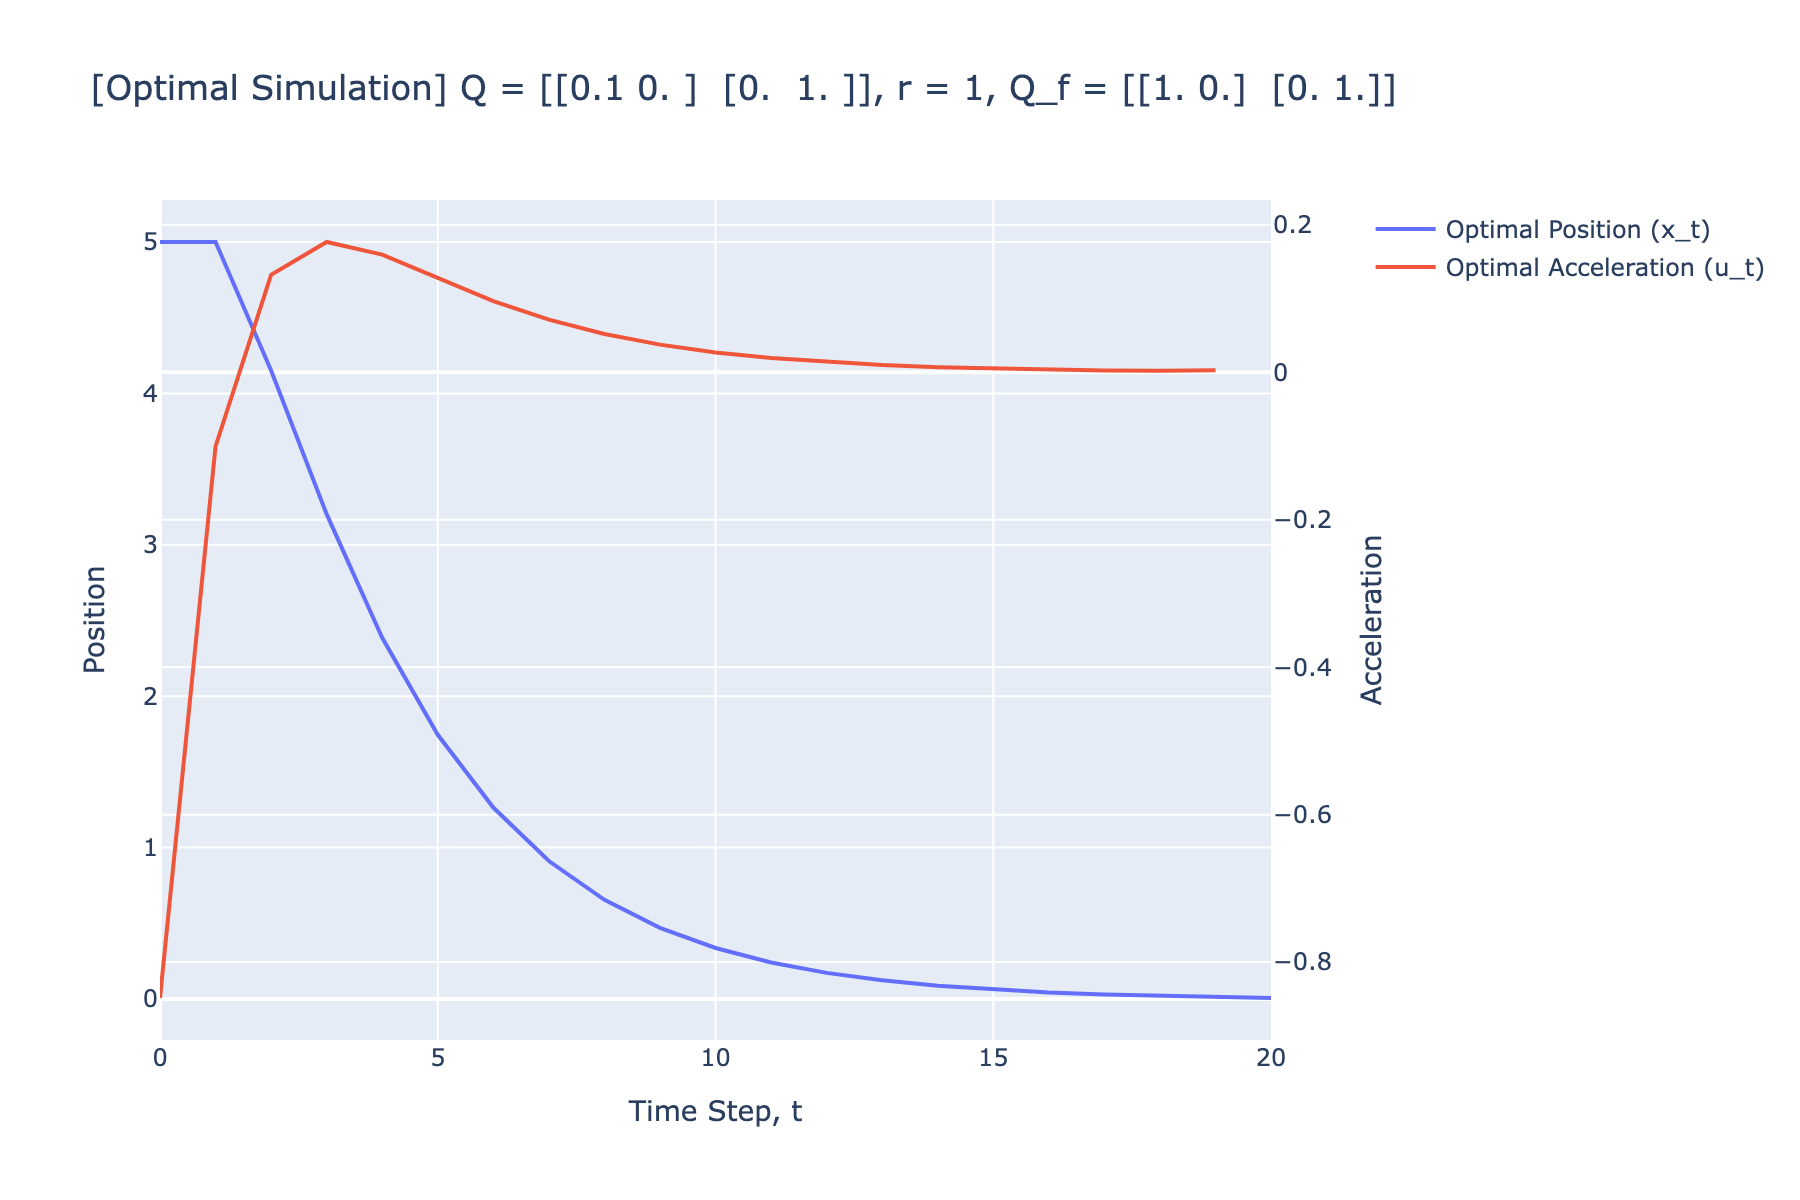

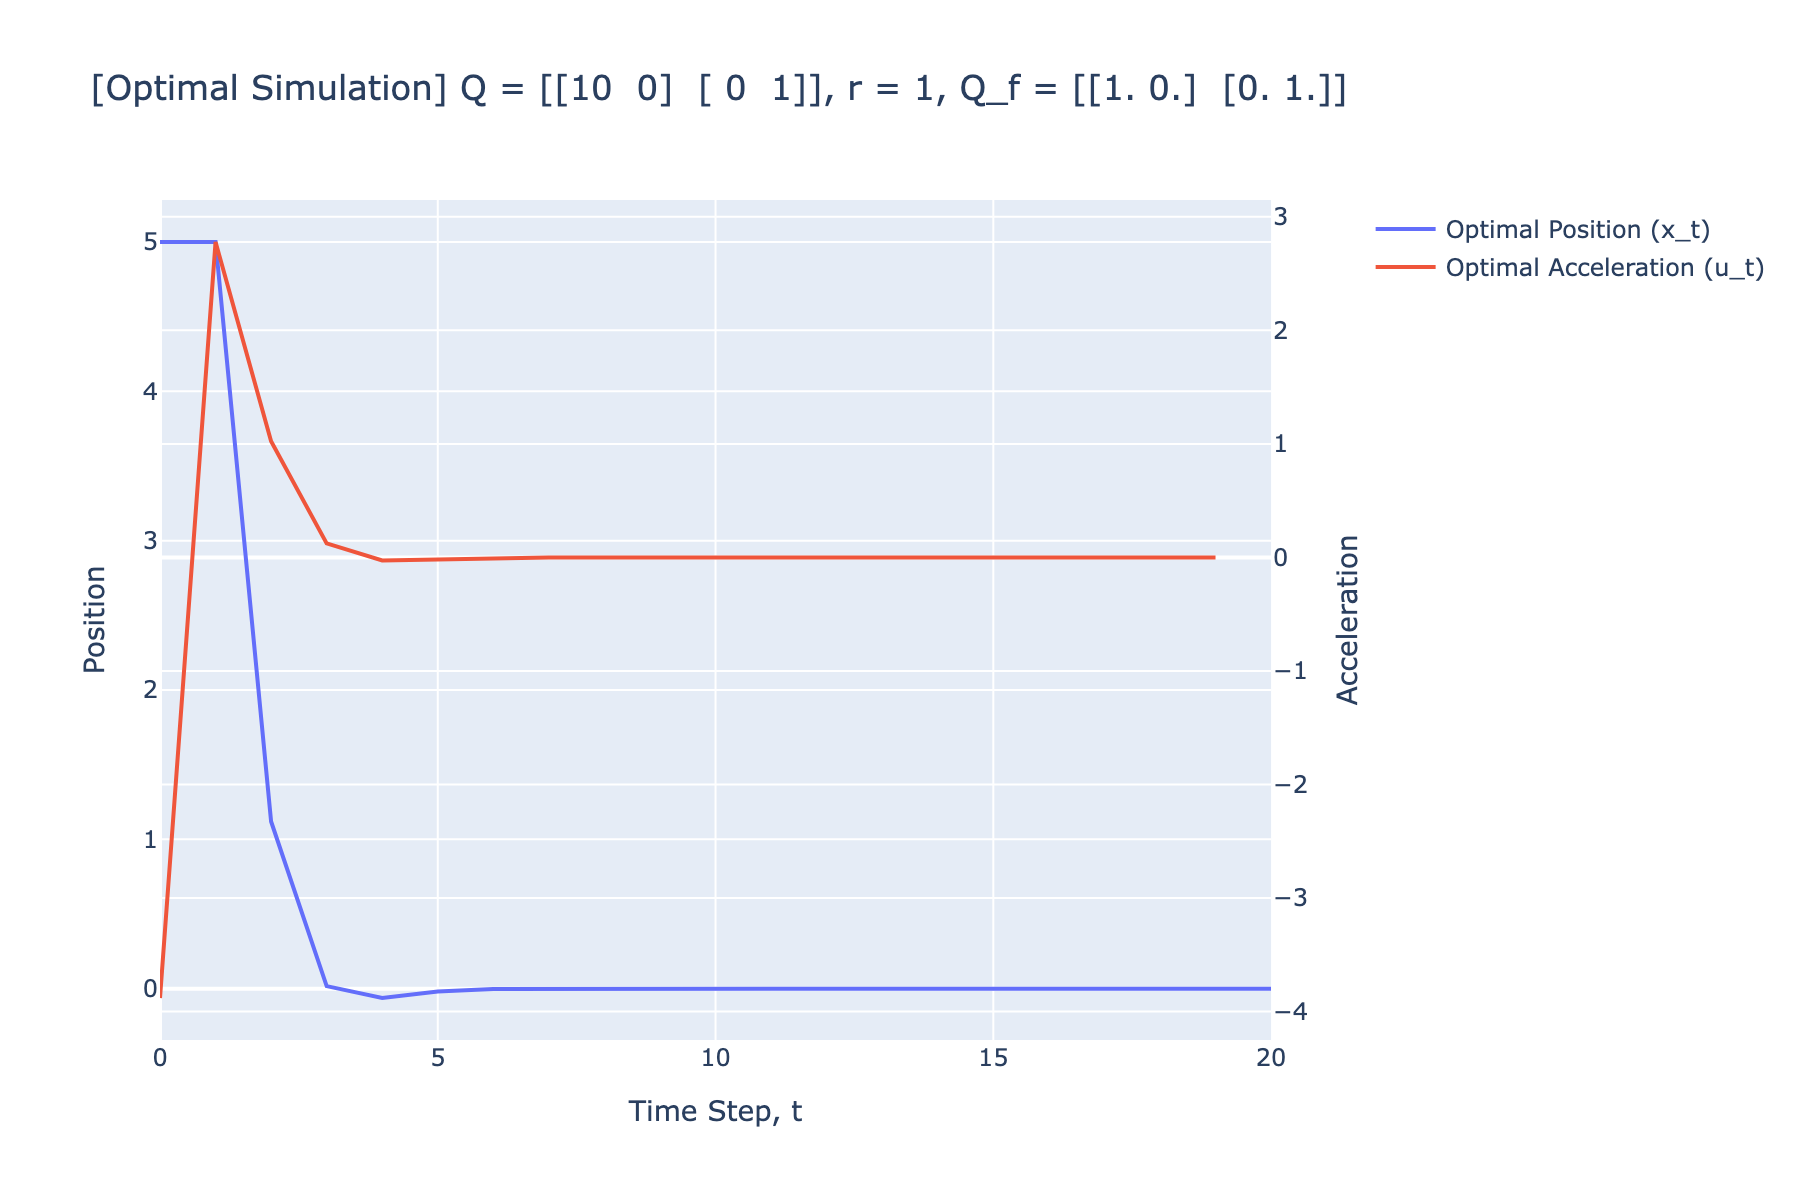

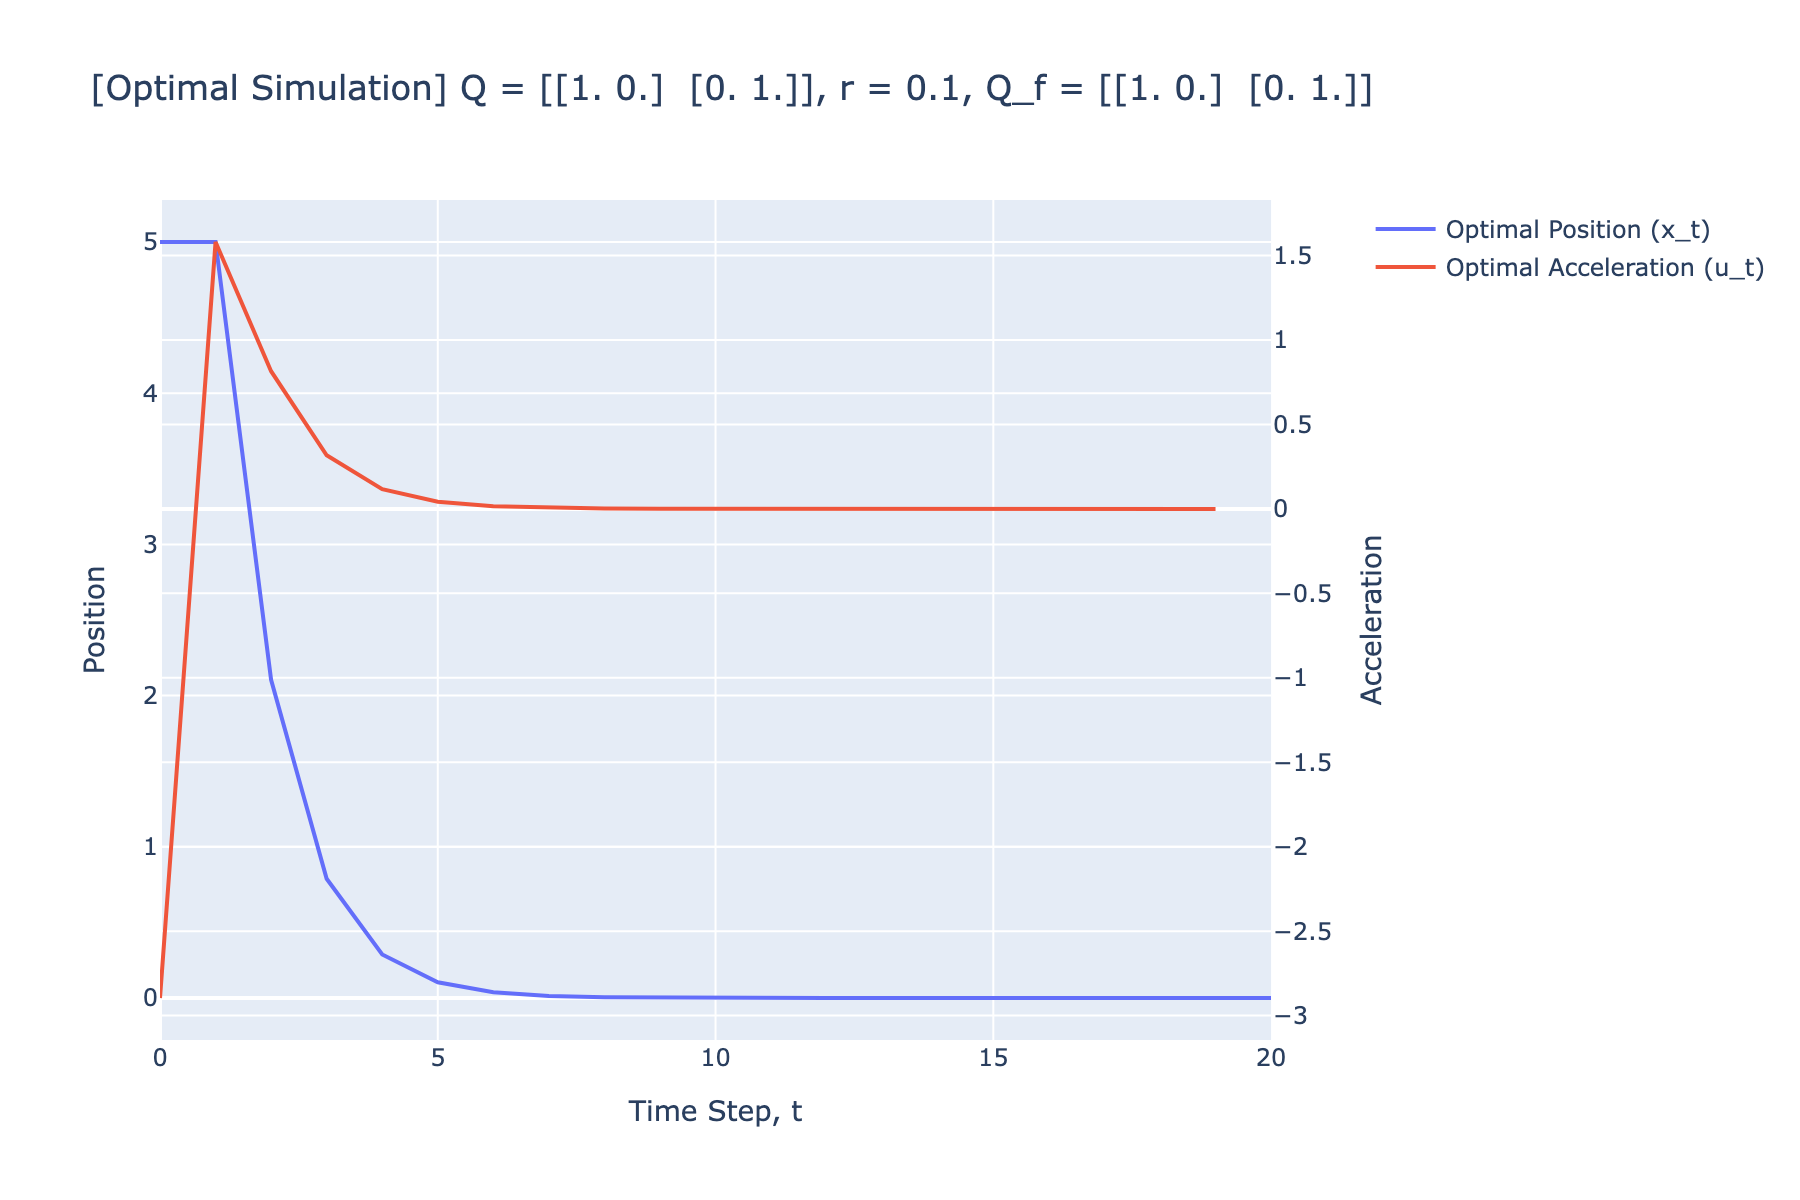

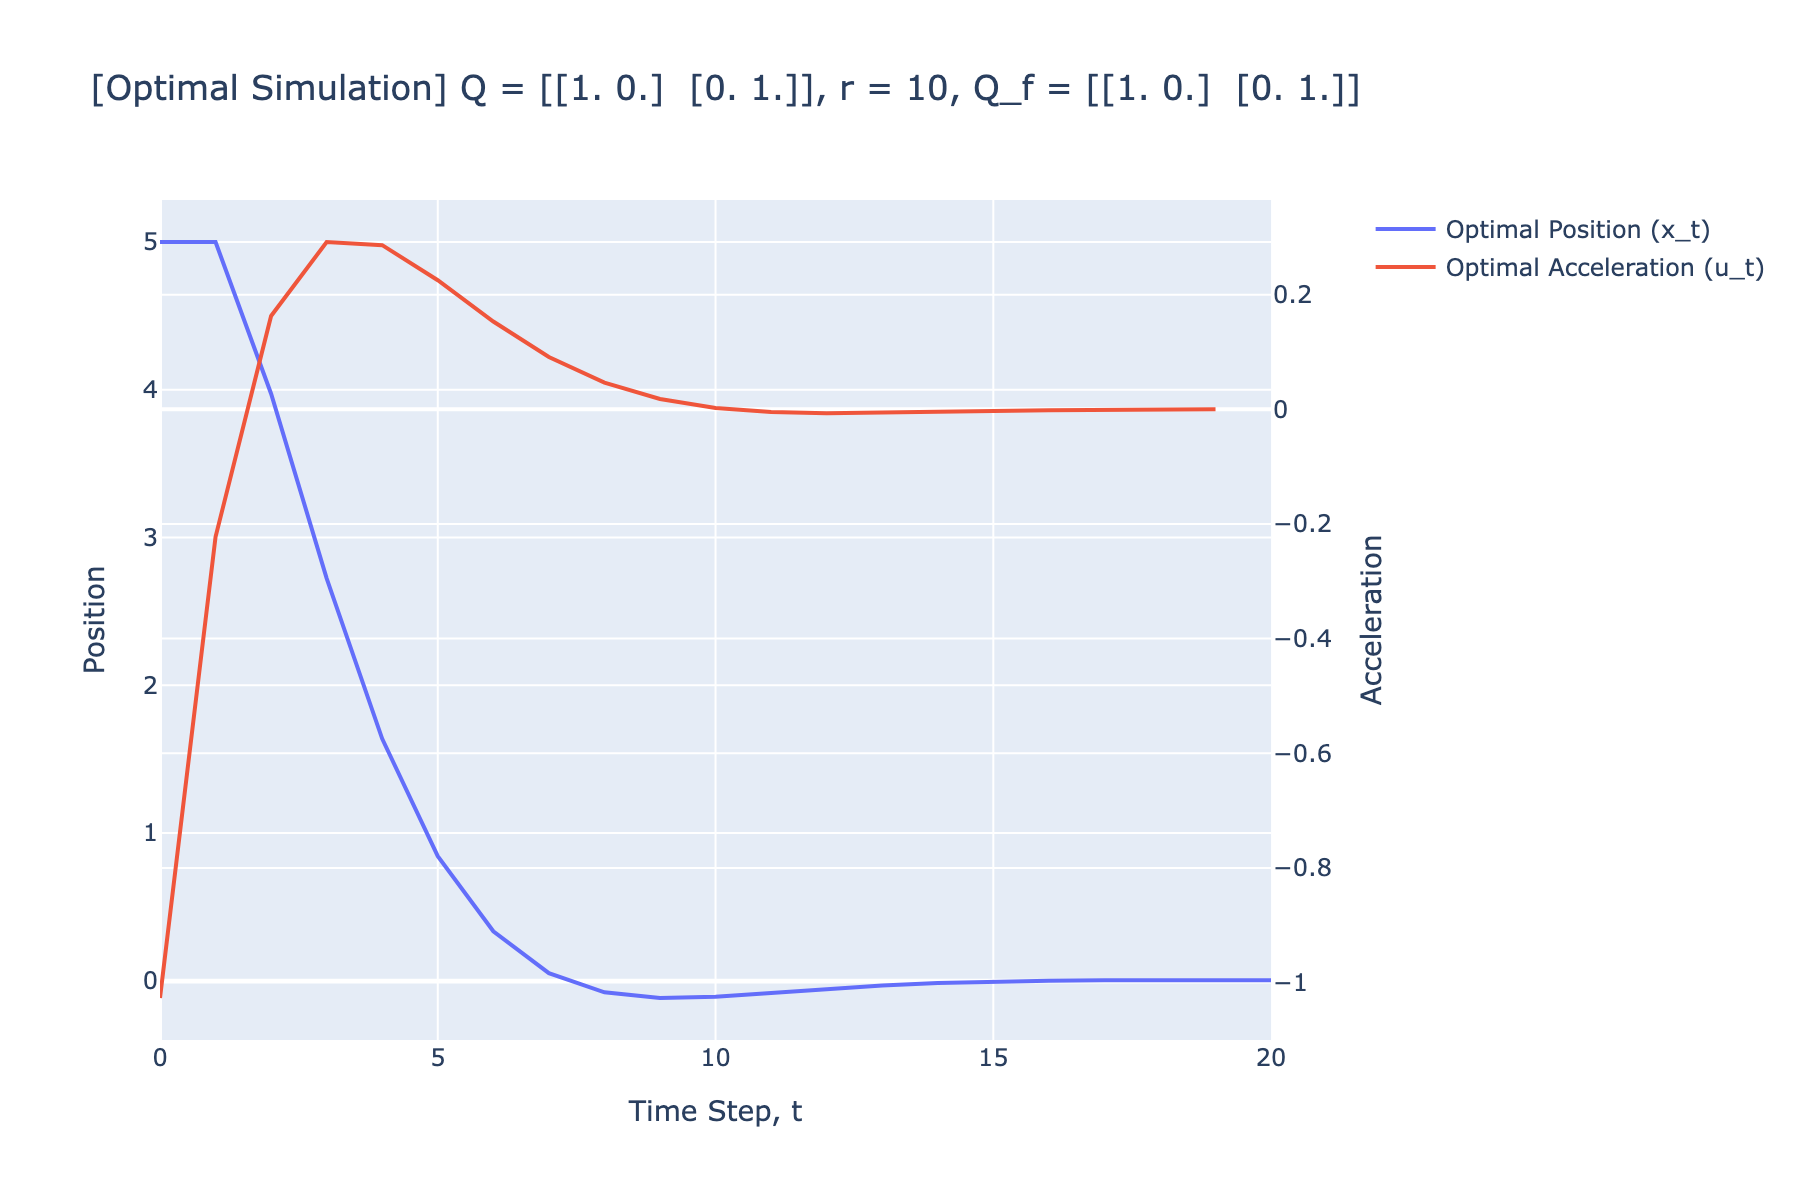

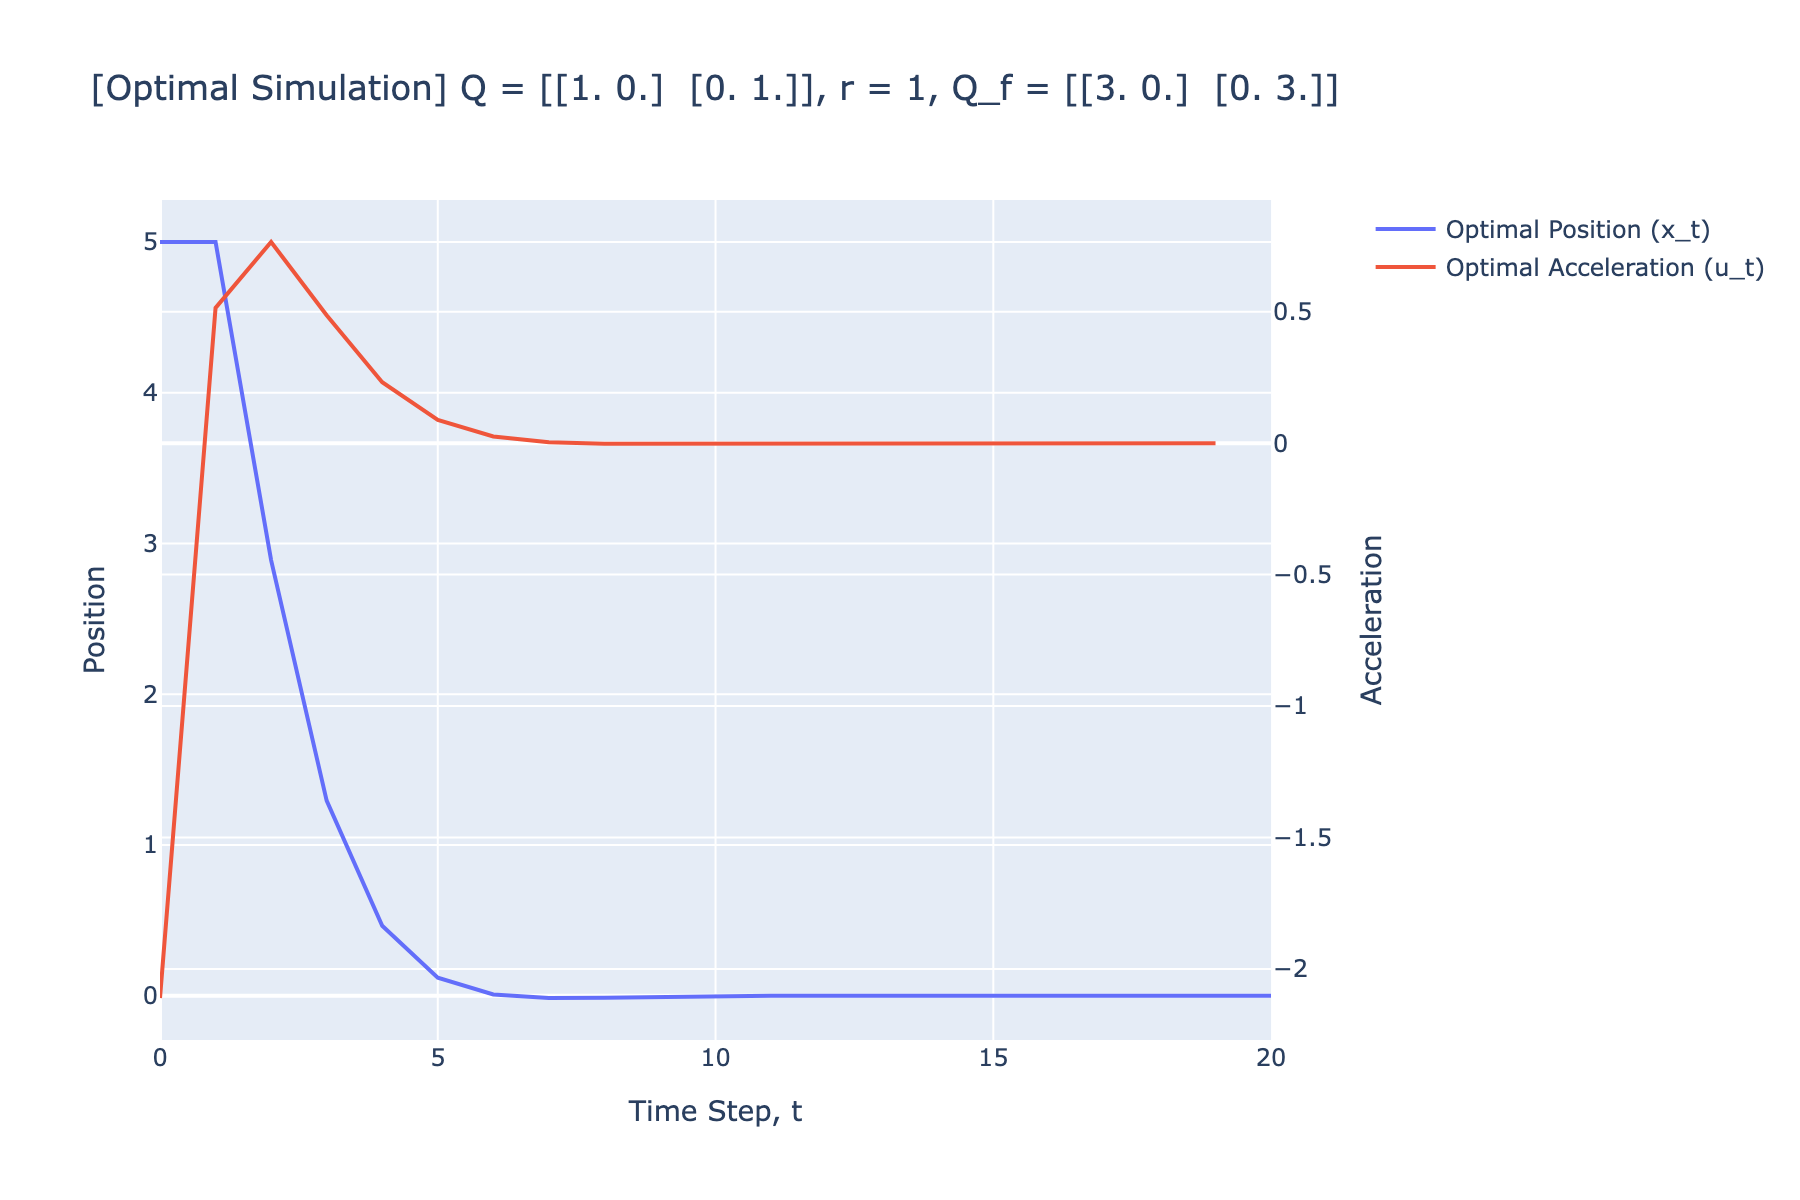

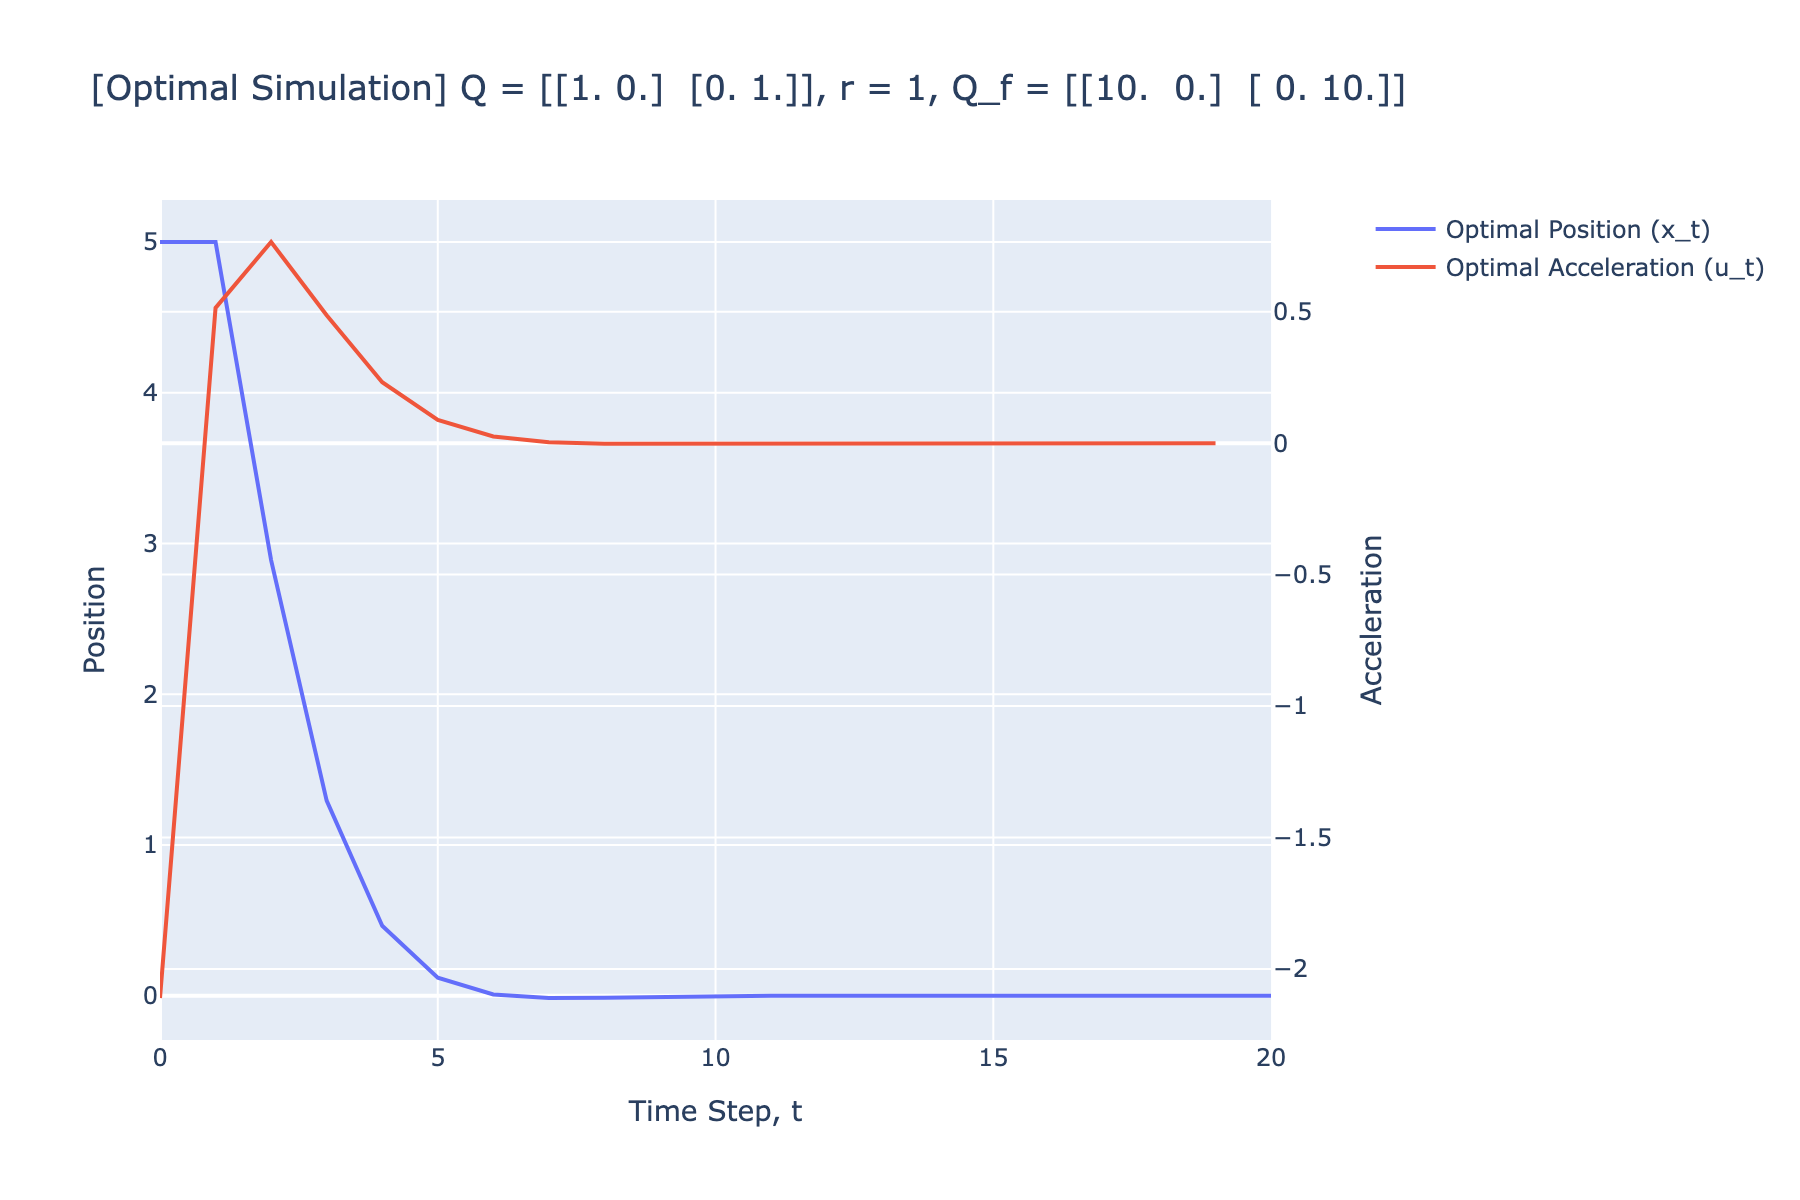

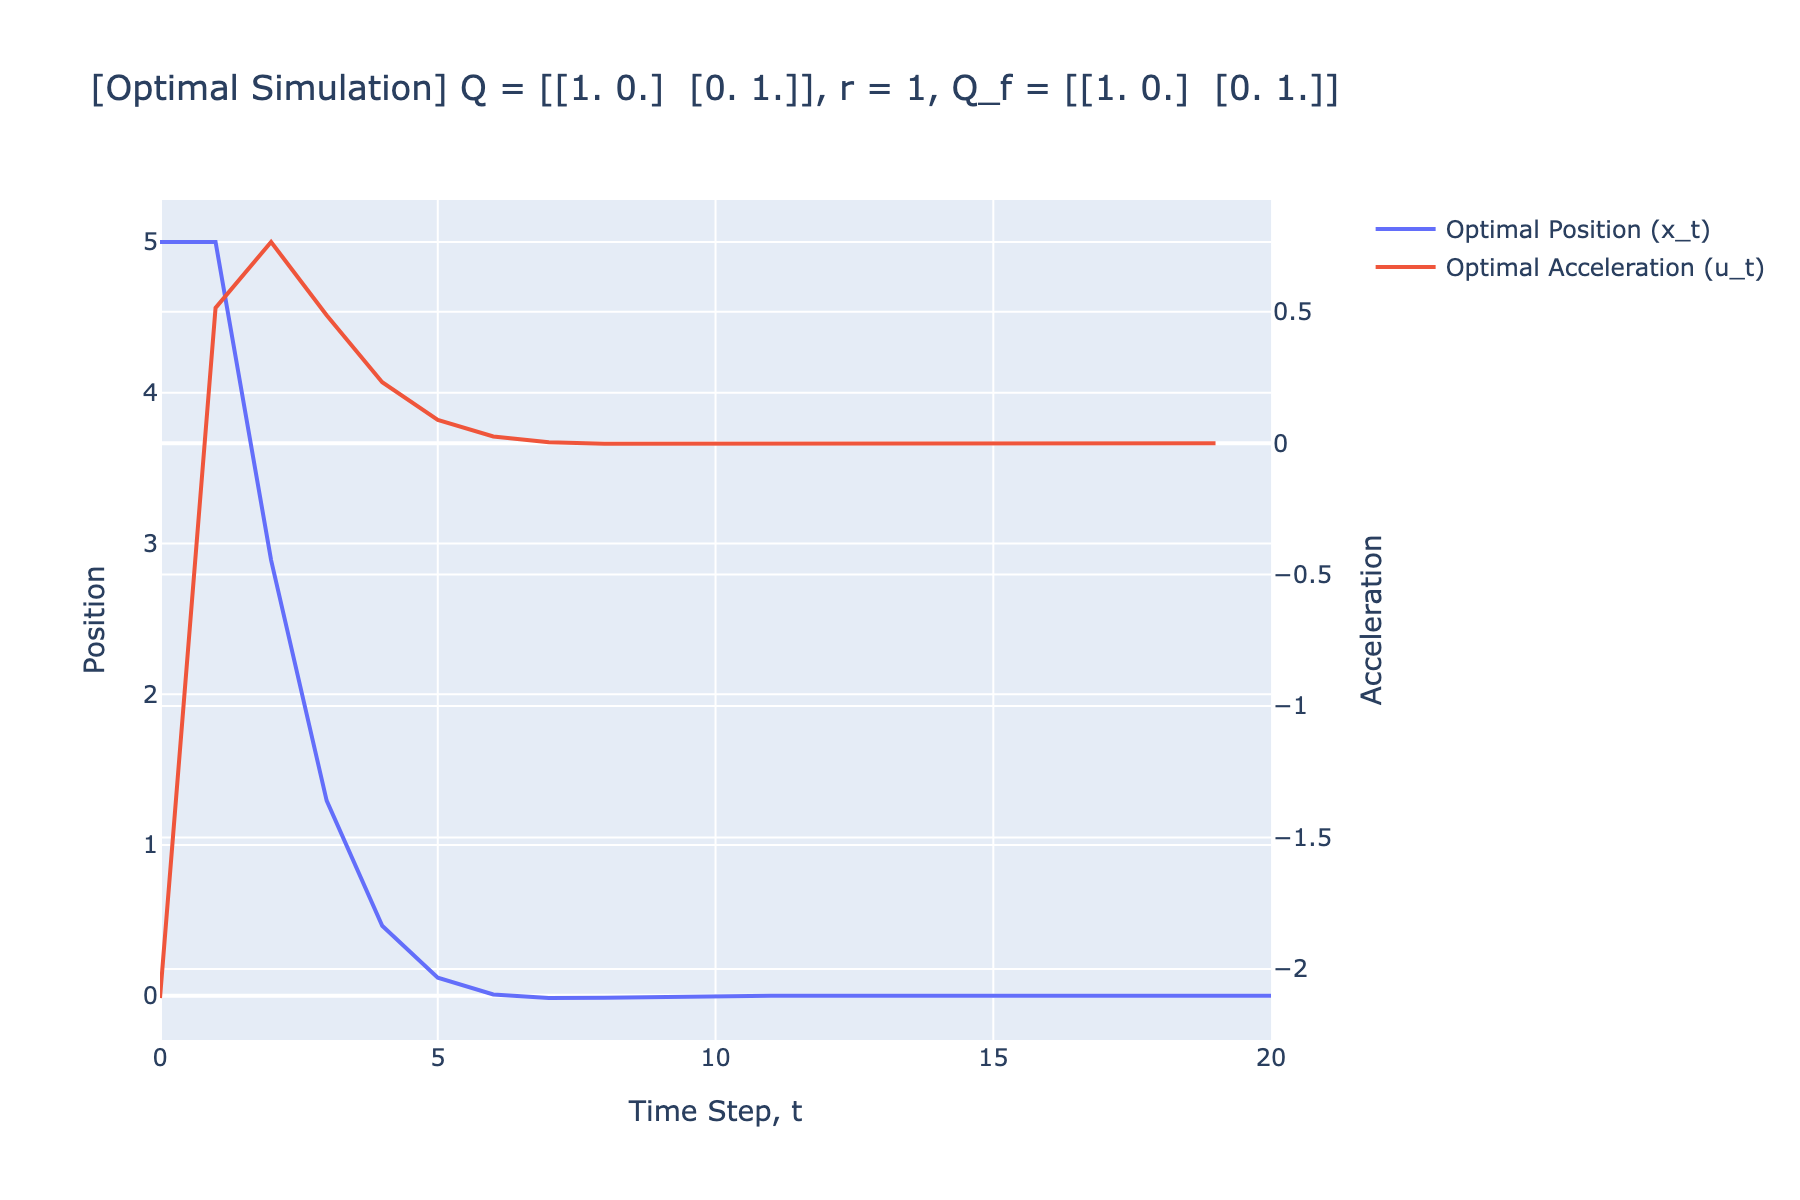

In [ ]:
from plotly.subplots import make_subplots


def plot_optimal_simulation(
    T: int,
    A: np.ndarray,
    B: np.ndarray,
    Q: np.ndarray,
    Q_f: np.ndarray,
    r: float,
    x_0: np.ndarray,
    dynamics: Callable,
    title: str | None = None,
) -> tuple[list[np.ndarray | None], list[np.ndarray | None]]:
    x_optimal, u_optimal = simulate_optimal(T, A, B, Q, Q_f, r, x_0, dynamics)
    p_optimal = [x[0][0] for x in x_optimal]
    v_optimal = [x[1][0] for x in x_optimal]

    title = f"[Optimal Simulation] Q = {Q}, r = {r}, Q_f = {Q_f}" if title is None else title

    # To match the time steps, x is one longer
    # u_optimal.append(np.ndarray([0]))

    t = list(range(len(p_optimal)))
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    # Optimal Position Trace
    fig.add_trace(
        go.Scatter(
            name="Optimal Position (x_t)",
            x=t,
            y=p_optimal,
        )
    )
    # Optimal Acceleration Trace
    u_optimal = [u[0][0] for u in u_optimal]
    fig.add_trace(go.Scatter(x=t, y=u_optimal, name="Optimal Acceleration (u_t)"), secondary_y=True)
    fig.update_layout(title=title, xaxis_title="Time Step, t", yaxis_title="Position")
    fig.update_yaxes(title_text="Acceleration", secondary_y=True)

    return fig


for penalty_name, param_set in penalty.items():
    for Q, r, Q_f in param_set:
        fig = plot_optimal_simulation(T, A, B, Q, Q_f, r, x_0, dynamics)
        fig.show()